In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from nanonets import Simulation
from nanonets.utils import BLUE_COLOR, RED_COLOR, GREEN_COLOR, get_displacement_currents, get_tau_f0_SET
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.linalg import eig
from scipy.interpolate import interp1d
from matplotlib.ticker import ScalarFormatter, NullLocator

plt.style.use(["science","bright","grid"])
%matplotlib inline

# PARAMS
N_VOLTAGES  = 50000
TIME_STEP   = 1.5e-11
STAT_SIZE   = 500
N_P_VALUES  = [3,5,7,9,11,13,15]
# N_P_VALUES  = [15]
N_ELECTRODE = 8
CPU_CNT     = 32
U0_LIST     = np.linspace(0.01,0.1,CPU_CNT,endpoint=False)
PLOT_NORM   = Normalize(vmin=1000*U0_LIST[0], vmax=1000*0.1)
TIME        = np.arange(N_VOLTAGES) * TIME_STEP
CMAP        = plt.get_cmap('cividis')
FOLDER      = "/home/jonasmensing/bagheera/data/2_funding_period/dynamic/DC/size_volt_028/"

### Linear Relaxation Time

In [ ]:
# Single Electron Tau and F0
TAU_SET, F0_SET = get_tau_f0_SET()

# Linear Limit
G_MAT   = {}
C_MAT   = {}
G_US    = {}
C_US    = {}
TAU_KCL = {}
for N_P in N_P_VALUES:
    # 8 Electrode Topology
    # Input: [(N_P-1)//2, 0]
    # Output: [(N_P-1)//2, N_P-1]
    topo = {"Nx": N_P,"Ny": N_P,
            "e_pos": [[(N_P-1)//2, 0],[0, 0],[N_P-1, 0], [0, (N_P-1)//2],
                      [N_P-1, (N_P-1)//2], [0, N_P-1],[N_P-1, N_P-1],[(N_P-1)//2, N_P-1]],
            "electrode_type": ['constant']*N_ELECTRODE}
    sim_c   = Simulation(topo)
    sim_c.build_conductance_matrix()

    # Get Capacitance and Conductance Matrices in Si Units
    C_MAT[N_P]  = sim_c.get_capacitance_matrix()*1e-18
    C_US[N_P]   = sim_c.get_electrode_capacitance_matrix().T*1e-18
    G_MAT[N_P]  = sim_c.get_conductance_matrix()[:-N_ELECTRODE,:-N_ELECTRODE]
    G_US[N_P]   = sim_c.get_conductance_matrix()[:-N_ELECTRODE,-N_ELECTRODE:]

    # Get real eigenvalues of internal matrices
    eig_val, _  = eig(G_MAT[N_P], C_MAT[N_P])
    real_eigs   = np.real(eig_val)
    valid_eigs  = real_eigs[real_eigs > 1e-9]

    # Tau as 1/eigenvalue
    TAU_KCL[N_P]  = 1e9 / valid_eigs

In [ ]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
ax      = sns.kdeplot(TAU_KCL, cut=3, ax=ax, palette='cividis', legend=False, gridsize=500, fill=True)
_       = ax.set_xlabel("$\\tau_k~[\mathrm{ns}]$")
# _       = ax.set_xlim(0.07,0.2)

norm        = mcolors.Normalize(vmin=N_P_VALUES[0], vmax=N_P_VALUES[-1])
cmap        = plt.get_cmap('cividis')
mappable    = cm.ScalarMappable(norm=norm, cmap=cmap)
cbar        = fig.colorbar(mappable, ax=ax, pad=0.02)

cbar.set_label("$L$", labelpad=10)
cbar.set_ticks(np.arange(N_P_VALUES[0], N_P_VALUES[-1] + 1, 2))

### Load Relaxation Data

In [ ]:
data    = {N : [pd.read_csv(f"{FOLDER}Nx={N}_Ny={N}_Ne=8_{V:.5f}_new.csv") for V in U0_LIST] for N in N_P_VALUES}
states  = {N : [pd.read_csv(f"{FOLDER}mean_state_Nx={N}_Ny={N}_Ne=8_{V:.5f}_new.csv") for V in U0_LIST] for N in N_P_VALUES}

In [ ]:
edge_idx = {}
bulk_idx = {}
for L in N_P_VALUES:
    edge_idx[L] = [n for n in range(L)]+[n*L for n in range(1,L-1)]+[n*L+(L-1) for n in range(1,L-1)]+[L*L-n for n in range(1,L+1)]
    bulk_idx[L] = [n for n in range(L*L) if n not in edge_idx[L]]

In [ ]:
# Potentials
x   = {N : [data[N][i]['E0'].values.copy() for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}
p   = {N : [states[N][i].iloc[:,8:].values.copy() for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}

# Bulk vs Edge
p_raw_bulk  = {N: [p[N][i][:, bulk_idx[N]] for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}
p_raw_edge  = {N: [p[N][i][:, edge_idx[N]] for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}
p_b         = {N: [np.mean(p_raw_bulk[N][i], axis=1) for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}
p_e         = {N: [np.mean(p_raw_edge[N][i], axis=1) for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}

# Currents
# y_t = {N : [data[N][i]['Observable'].values.copy() for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}
# y_e = {N : [data[N][i]['Error'].values.copy() for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}
# y_d = {N : [get_displacement_currents(p[N][i], C_US[N], TIME_STEP) for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}
# y   = {N : [y_t[N][i]+y_d[N][i] for i, _ in enumerate(U0_LIST)] for N in N_P_VALUES}

In [ ]:
for N in N_P_VALUES:
    for i, V in enumerate(U0_LIST):
        np.save(f"relaxation_data_028/p_bulk_{N}_{V:.5f}.npy", p_b[N][i])
        np.save(f"relaxation_data_028/p_edge_{N}_{V:.5f}.npy", p_e[N][i])
        # np.save(f"relaxation_data/I_t_{N}_{V:.5f}.npy", y_t[N][i])
        # np.save(f"relaxation_data/I_d_{N}_{V:.5f}.npy", y_d[N][i])
        # np.save(f"relaxation_data/I_e_{N}_{V:.5f}.npy", y_e[N][i])
        # np.save(f"relaxation_data/I_{N}_{V:.5f}.npy", y[N][i])

In [15]:
p_b = {}
p_e = {}
y   = {}
y_d = {}
y_t = {}
y_e = {}
for N in N_P_VALUES:
    p_b[N]  = [np.load(f"relaxation_data_028/p_bulk_{N}_{V:.5f}.npy") for V in U0_LIST]
    p_e[N]  = [np.load(f"relaxation_data_028/p_edge_{N}_{V:.5f}.npy") for V in U0_LIST]
    # y[N]    = [np.load(f"relaxation_data/I_{N}_{V:.5f}.npy") for V in U0_LIST]
    # y_t[N]  = [np.load(f"relaxation_data/I_t_{N}_{V:.5f}.npy") for V in U0_LIST]
    # y_d[N]  = [np.load(f"relaxation_data/I_d_{N}_{V:.5f}.npy") for V in U0_LIST]
    # y_e[N]  = [np.load(f"relaxation_data/I_e_{N}_{V:.5f}.npy") for V in U0_LIST]

### Relaxation Curves

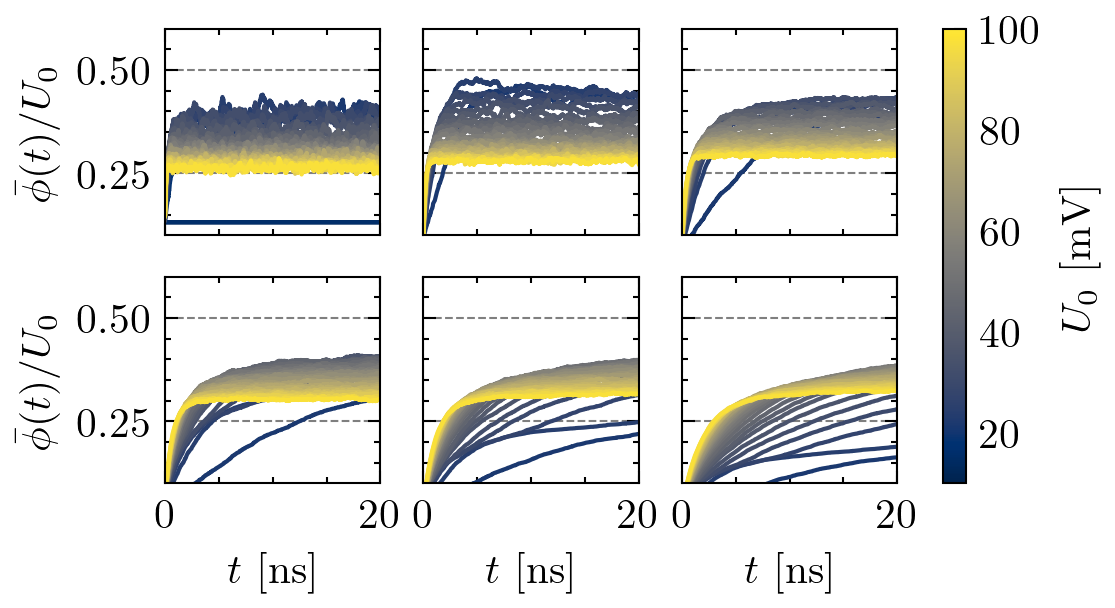

In [16]:
fig     = plt.figure(dpi=300)
fig.set_figwidth(fig.get_figwidth()*1.5)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
axs     = []
for i, N_NP in enumerate([3,5,7,9,11,13]):
    ax  = fig.add_subplot(2,3,i+1)
    for j, V in enumerate(U0_LIST):
        t_copy  = TIME.copy()*1e9
        y_copy  = p_b[N_NP][j].copy()/V
        ax.plot(t_copy, y_copy, color=CMAP(PLOT_NORM(V*1000)))
    _ = ax.set_xlim(0, 20)
    _ = ax.set_ylim(0.1, 0.6)
    if i >= 3:
        _ = ax.set_xlabel("$t$ [ns]")
    else:
        _ = ax.set_xticklabels("")
    if (i % 3) == 0:
        _ = ax.set_ylabel("$\\bar{\\phi}(t)/U_0$")
    else:
        _ = ax.set_yticklabels("")
    axs.append(ax)

sm  = ScalarMappable(cmap=CMAP, norm=PLOT_NORM)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs)
cbar.set_label("$U_0$ [mV]")

fig.savefig(f"plots/png/pot_relaxation_028.png", transparent=False)
fig.savefig(f"plots/pdf/pot_relaxation_028.pdf", transparent=False)
fig.savefig(f"plots/svg/pot_relaxation_028.svg", transparent=True)

### Fitting Tau

In [17]:
def tau_exp_fit(t, y, min_range=0.005, kohlrausch=True):

    # Check if curve is flat
    signal_range = np.max(y) - np.min(y)
    if signal_range < min_range:
        return np.nan, np.nan, np.nan
    
    # Time
    t_ns = t * 1e9
    # Displacement Offset
    y_start = y[0]
    # Steady State
    y_end = np.median(y[int(len(y)*0.95):])
    # Difference
    A_fixed = y_end - y_start

    # Guess Tau
    th_val  = y_start + 0.632 * A_fixed
    if A_fixed > 0:
        cross_idx = np.where(y > th_val)[0]
    else:
        cross_idx = np.where(y < th_val)[0]
    if len(cross_idx) > 0:
        guess_tau = t_ns[cross_idx[0]]
    else:
        guess_tau = 0.1

    # Kohlraus Fit
    if kohlrausch:
        def relaxation_model(t_vals, tau, beta):
            return y_start + A_fixed * (1 - np.exp(-(t_vals / tau)**beta))
        p0 = [guess_tau, 1.0]
        # bounds = ([1e-6, 0.1], [np.inf, 1.0])
        bounds = ([0.0, 0.0], [np.inf, 1.0])
    # Exponential Fit
    else:
        def relaxation_model(t_vals, tau):
            return y_start + A_fixed * (1 - np.exp(-t_vals / tau))
        p0 = [guess_tau]
        # bounds = (1e-6, np.inf)
        bounds = (0.0, np.inf)
    try:
        # Fit Curve
        popt, pcov = curve_fit(relaxation_model, t_ns, y, p0=p0, bounds=bounds)
        # For Kohlrausch return <tau>, beta
        if kohlrausch:
            tau_k   = popt[0]
            beta    = popt[1]
            tau_fit = (tau_k / beta) * gamma(1 / beta)
            return tau_fit * 1e-9, beta, pcov
        # For exp Fit return tau
        else:
            tau_fit = popt[0]
            return tau_fit * 1e-9, 1.0, pcov
    except RuntimeError:
        return np.nan, np.nan, np.nan

### Tau Curves

In [18]:
kohlrausch  = True
taus_b      = {}
taus_e      = {}
betas_b     = {}
betas_e     = {}
covs_b      = {}
covs_e      = {}
for N_NP in N_P_VALUES:
    taus_b[N_NP]    = []
    taus_e[N_NP]    = []
    betas_b[N_NP]   = []
    betas_e[N_NP]   = []
    covs_b[N_NP]    = []
    covs_e[N_NP]    = []
    for i, V in enumerate(U0_LIST):

        t_copy          = TIME.copy()
        y_copy          = p_b[N_NP][i].copy()/V
        tau, beta, cov  = tau_exp_fit(t_copy, y_copy, kohlrausch=kohlrausch)
        taus_b[N_NP].append(tau*1e9)
        betas_b[N_NP].append(beta)
        covs_b[N_NP].append(cov)

        t_copy          = TIME.copy()
        y_copy          = p_e[N_NP][i].copy()/V
        tau, beta, cov  = tau_exp_fit(t_copy, y_copy, kohlrausch=kohlrausch)
        taus_e[N_NP].append(tau*1e9)
        betas_e[N_NP].append(beta)
        covs_e[N_NP].append(cov)

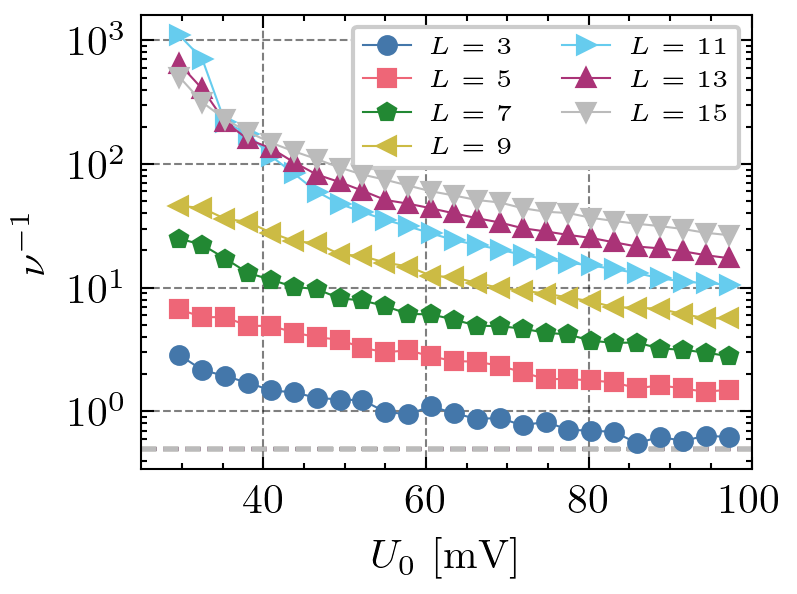

In [30]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
V_write = np.array(U0_LIST)*1000
marker  = ['o','s','p','<','>','^','v']
skip    = 7

for i, N_NP in enumerate(N_P_VALUES):
    taus    = taus_b[N_NP]
    pp      = ax.plot(V_write[skip:], taus[skip:]/(1e9*TAU_SET), marker=marker[i], ms=4, ls='-', label=f'$L = {N_NP}$', lw=0.5, markevery=1, zorder=10)
    _       = plt.axhline(np.max(TAU_KCL[N_NP])/(1e9*TAU_SET), color=pp[0].get_color(), ls='--')
    
_ = ax.set_yscale('log')
_ = ax.set_xlim(25, 100)
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$\\nu^{-1}$")
_ = ax.legend(fontsize='xx-small', frameon=True, ncol=2, loc='upper right')

fig.savefig(f"plots/png/bulk_nu_vs_U0_028.png", transparent=False)
fig.savefig(f"plots/pdf/bulk_nu_vs_U0_028.pdf", transparent=False)
fig.savefig(f"plots/svg/bulk_nu_vs_U0_028.svg", transparent=True)

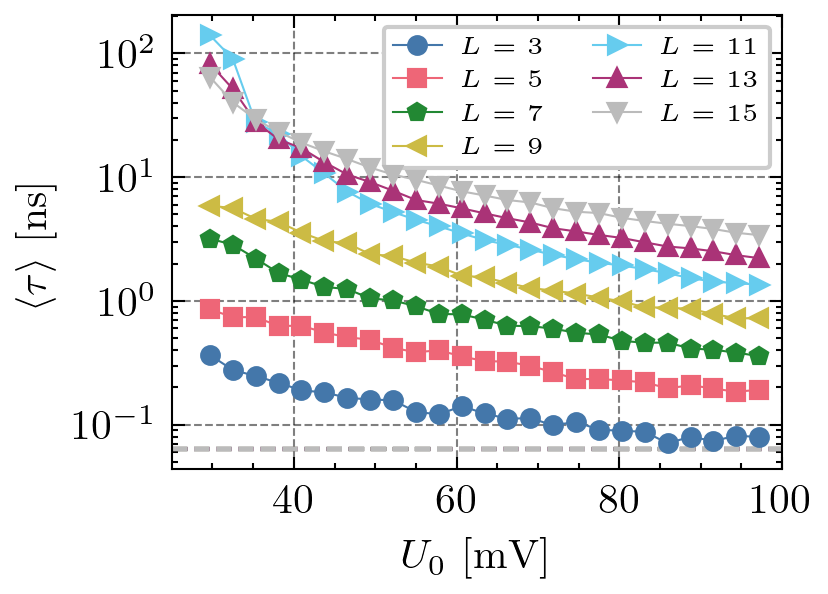

In [31]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
V_write = np.array(U0_LIST)*1000
marker  = ['o','s','p','<','>','^','v']
skip    = 7

for i, N_NP in enumerate(N_P_VALUES):
    taus    = taus_b[N_NP]
    pp      = ax.plot(V_write[skip:], taus[skip:], marker=marker[i], ms=4, ls='-', label=f'$L = {N_NP}$', lw=0.5, markevery=1, zorder=10)
    _       = plt.axhline(np.max(TAU_KCL[N_NP]), color=pp[0].get_color(), ls='--')
    
_ = ax.set_yscale('log')
_ = ax.set_xlim(25, 100)
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$\\langle\\tau\\rangle$ [ns]")
_ = ax.legend(fontsize='xx-small', frameon=True, ncol=2, loc='upper right')

fig.savefig(f"plots/png/bulk_tau_vs_U0_028.png", transparent=False)
fig.savefig(f"plots/pdf/bulk_tau_vs_U0_028.pdf", transparent=False)
fig.savefig(f"plots/svg/bulk_tau_vs_U0_028.svg", transparent=True)

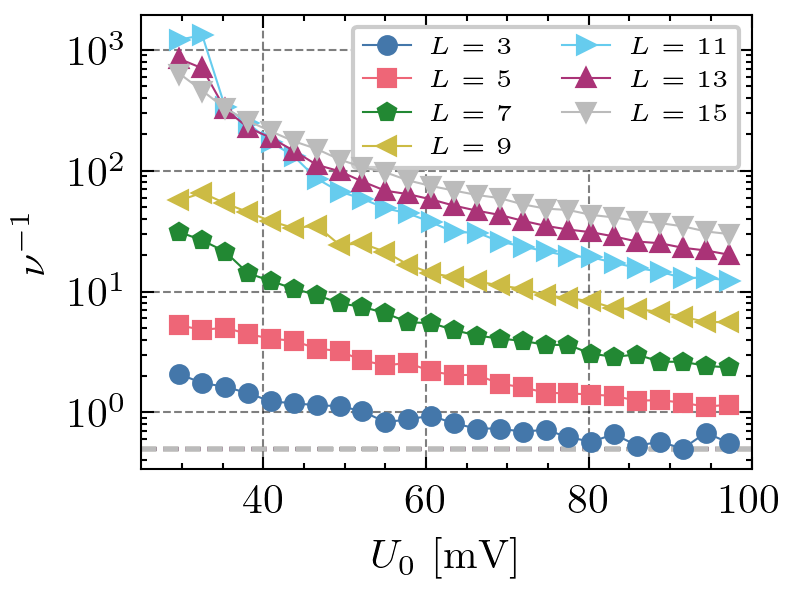

In [32]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
V_write = np.array(U0_LIST)*1000
marker  = ['o','s','p','<','>','^','v']
skip    = 7

for i, N_NP in enumerate(N_P_VALUES):
    taus    = taus_e[N_NP]
    pp      = ax.plot(V_write[skip:], taus[skip:]/(1e9*TAU_SET), marker=marker[i], ms=4, ls='-', label=f'$L = {N_NP}$', lw=0.5, markevery=1, zorder=10)
    _       = plt.axhline(np.max(TAU_KCL[N_NP])/(1e9*TAU_SET), color=pp[0].get_color(), ls='--')
    
_ = ax.set_yscale('log')
_ = ax.set_xlim(25, 100)
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$\\nu^{-1}$")
_ = ax.legend(fontsize='xx-small', frameon=True, ncol=2, loc='upper right')

fig.savefig(f"plots/png/edge_nu_vs_U0_028.png", transparent=False)
fig.savefig(f"plots/pdf/edge_nu_vs_U0_028.pdf", transparent=False)
fig.savefig(f"plots/svg/edge_nu_vs_U0_028.svg", transparent=True)

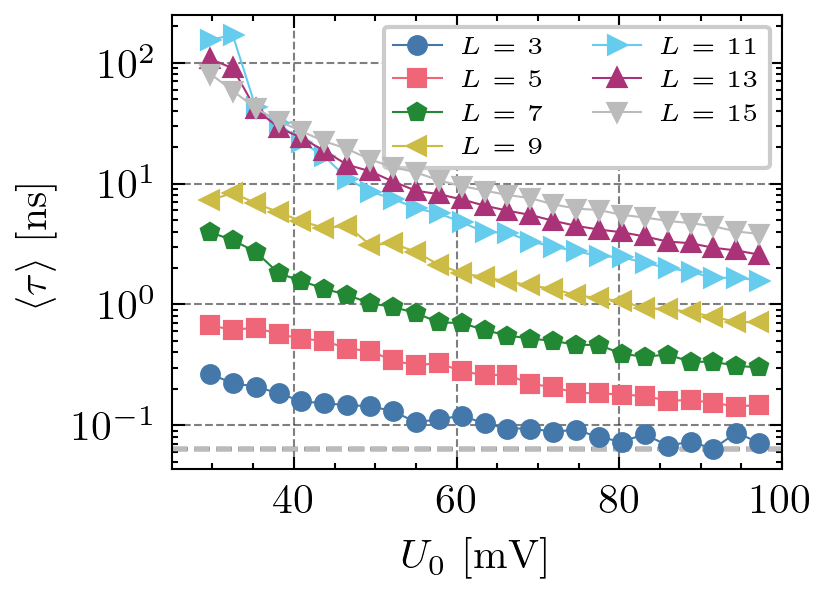

In [33]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
V_write = np.array(U0_LIST)*1000
marker  = ['o','s','p','<','>','^','v']
skip    = 7

for i, N_NP in enumerate(N_P_VALUES):
    taus    = taus_e[N_NP]
    pp      = ax.plot(V_write[skip:], taus[skip:], marker=marker[i], ms=4, ls='-', label=f'$L = {N_NP}$', lw=0.5, markevery=1, zorder=10)
    _       = plt.axhline(np.max(TAU_KCL[N_NP]), color=pp[0].get_color(), ls='--')
    
_ = ax.set_yscale('log')
_ = ax.set_xlim(25, 100)
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$\\langle\\tau\\rangle$ [ns]")
_ = ax.legend(fontsize='xx-small', frameon=True, ncol=2, loc='upper right')

fig.savefig(f"plots/png/edge_tau_vs_U0_028.png", transparent=False)
fig.savefig(f"plots/pdf/edge_tau_vs_U0_028.pdf", transparent=False)
fig.savefig(f"plots/svg/edge_tau_vs_U0_028.svg", transparent=True)

### Tau vs L Plot

In [34]:
AMPLITUDE_LIST  = {3: 0.0128, 4: 0.0166, 5: 0.0168, 6: 0.0185, 7: 0.0186, 8: 0.0195, 9: 0.0195,
                   10: 0.0200, 11: 0.0201, 12: 0.0203, 13: 0.0203, 14: 0.0205, 15: 0.0205}

In [35]:
tau_th_b = []
tau_th_e = []

for N in N_P_VALUES:

    u0_values   = np.array(U0_LIST)
    p_values    = np.array(taus_b[N])
    func        = interp1d(u0_values,p_values)
    tau_at_th   = func(2*AMPLITUDE_LIST[N])
    tau_th_b.append(tau_at_th)

    u0_values   = np.array(U0_LIST)
    p_values    = np.array(taus_e[N])
    func        = interp1d(u0_values,p_values)
    tau_at_th   = func(2*AMPLITUDE_LIST[N])
    tau_th_e.append(tau_at_th)

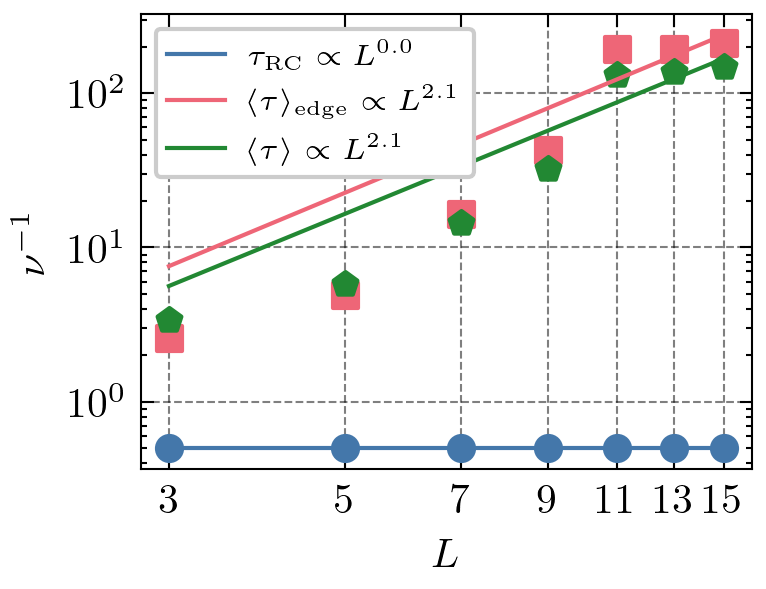

In [46]:
def power_law(x, a, gamma):
    return a * x**(gamma)

s_i     = 1
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)

x_plot  = np.array(N_P_VALUES)
y_plot  = np.array([np.max(TAU_KCL[N]) for N in N_P_VALUES])/(1e9*TAU_SET)
p,_     = curve_fit(power_law, x_plot[s_i:], y_plot[s_i:])
pp      = ax.scatter(x_plot, y_plot, marker='o')
_       = ax.plot(x_plot, power_law(x_plot, *p), label=f'$\\tau_\\textrm{{RC}} \\propto L^{{{np.round(p[1],1)}}}$')

s_i     = 0
y_plot  = np.array(tau_th_e)/(1e9*TAU_SET)
p,_     = curve_fit(power_law, x_plot[s_i:], y_plot[s_i:])
pp      = ax.scatter(x_plot, y_plot, marker='s')
_       = ax.plot(x_plot, power_law(x_plot, *p), label=f'$\\langle\\tau\\rangle_\\textrm{{edge}} \\propto L^{{{np.round(p[1],1)}}}$')

s_i     = 0
y_plot  = np.array(tau_th_b)/(1e9*TAU_SET)
p,_     = curve_fit(power_law, x_plot[s_i:], y_plot[s_i:])
pp      = ax.scatter(x_plot, y_plot, marker='p')
_       = ax.plot(x_plot, power_law(x_plot, *p), label=f'$\\langle\\tau\\rangle \\propto L^{{{np.round(p[1],1)}}}$')

_   = ax.set_xlabel('$L$')
_   = ax.set_ylabel("$\\nu^{-1}$")
_   = ax.legend(fontsize='x-small')
_   = ax.set_xscale('log')
_   = ax.set_yscale('log')
_   = ax.set_xticks(N_P_VALUES)
_   = ax.xaxis.set_major_formatter(ScalarFormatter())
_   = ax.xaxis.set_minor_locator(NullLocator())
# ax.xaxis.set_minor_formatter(ScalarFormatter())

# fig.savefig(f"plots/png/nu_L_scaling_028.png", transparent=False)
# fig.savefig(f"plots/pdf/nu_L_scaling_028.pdf", transparent=False)
# fig.savefig(f"plots/svg/nu_L_scaling_028.svg", transparent=True)

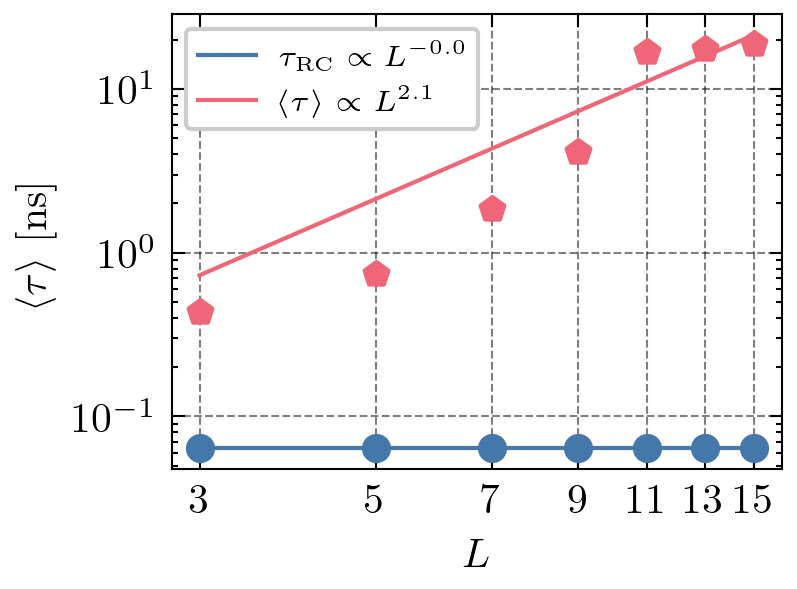

In [43]:
def power_law(x, a, gamma):
    return a * x**(gamma)

s_i     = 1
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)

x_plot  = np.array(N_P_VALUES)
y_plot  = np.array([np.max(TAU_KCL[N]) for N in N_P_VALUES])
p,_     = curve_fit(power_law, x_plot[s_i:], y_plot[s_i:])
pp      = ax.scatter(x_plot, y_plot, marker='o')
_       = ax.plot(x_plot, power_law(x_plot, *p), label=f'$\\tau_\\textrm{{RC}} \\propto L^{{{np.round(p[1],1)}}}$')

# s_i     = 1
# y_plot  = np.array(tau_th_e)
# p,_     = curve_fit(power_law, x_plot[s_i:], y_plot[s_i:])
# pp      = ax.scatter(x_plot, y_plot, marker='s')
# _       = ax.plot(x_plot, power_law(x_plot, *p), label=f'$\\langle\\tau\\rangle_\\textrm{{edge}} \\propto L^{{{np.round(p[1],1)}}}$')

s_i     = 1
y_plot  = np.array(tau_th_b)
p,_     = curve_fit(power_law, x_plot[s_i:], y_plot[s_i:])
pp      = ax.scatter(x_plot, y_plot, marker='p')
_       = ax.plot(x_plot, power_law(x_plot, *p), label=f'$\\langle\\tau\\rangle \\propto L^{{{np.round(p[1],1)}}}$')

_   = ax.set_xlabel('$L$')
_   = ax.set_ylabel("$\\langle\\tau\\rangle$ [ns]")
_   = ax.legend(fontsize='x-small')
_   = ax.set_xscale('log')
_   = ax.set_yscale('log')
_   = ax.set_xticks(N_P_VALUES)
_   = ax.xaxis.set_major_formatter(ScalarFormatter())
_   = ax.xaxis.set_minor_locator(NullLocator())
# ax.xaxis.set_minor_formatter(ScalarFormatter())

fig.savefig(f"plots/png/tau_L_scaling_028.png", transparent=False)
fig.savefig(f"plots/pdf/tau_L_scaling_028.pdf", transparent=False)
fig.savefig(f"plots/svg/tau_L_scaling_028.svg", transparent=True)

### Beta Distribution

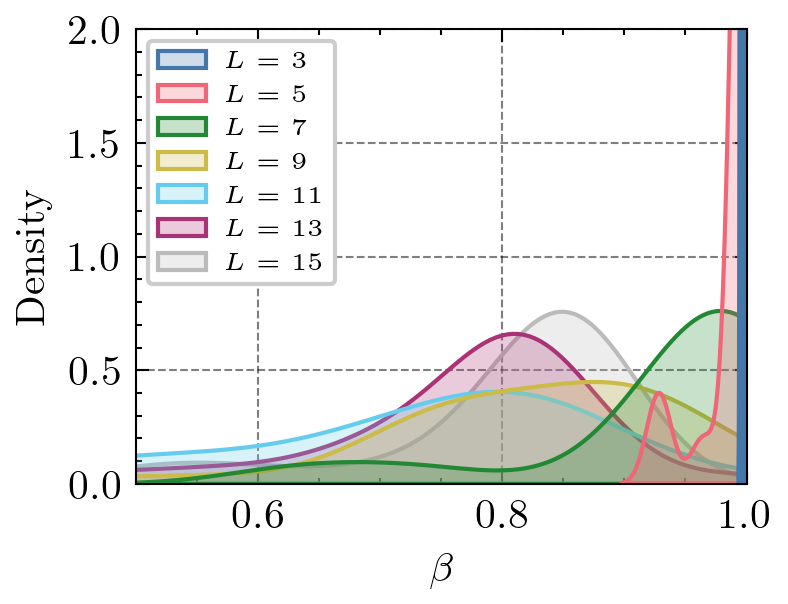

In [40]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)

ax  = sns.kdeplot(pd.DataFrame(betas_b).rename(columns={N : f"$L = {N}$" for N in N_P_VALUES}), fill=True)
_ = ax.set_xlim(0.5,1)
_ = ax.set_ylim(0,2)
_ = ax.set_xlabel("$\\beta$")
sns.move_legend(ax, 'upper left', fontsize='xx-small', ncol=1)

# fig.savefig(f"plots/png/beta_vs_L_028.png", transparent=False)
# fig.savefig(f"plots/pdf/beta_vs_L_028.pdf", transparent=False)
# fig.savefig(f"plots/svg/beta_vs_L_028.svg", transparent=True)

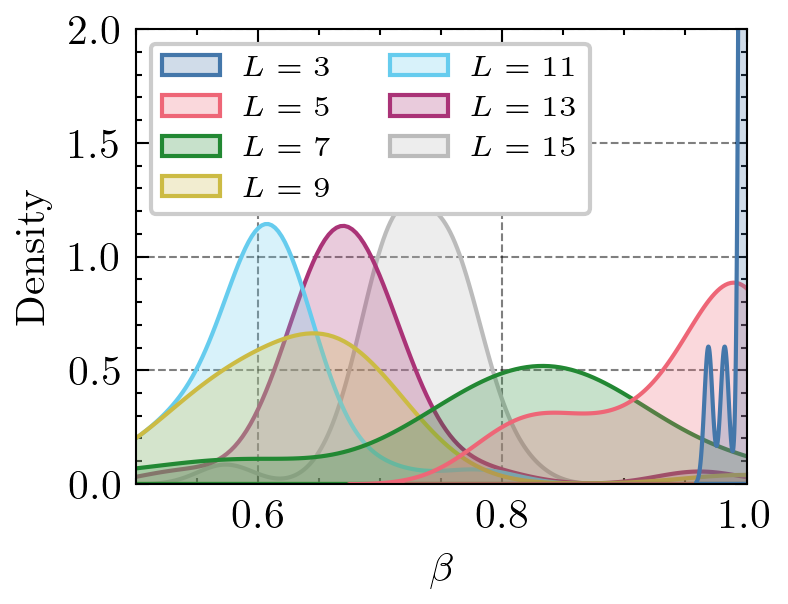

In [41]:
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)

ax  = sns.kdeplot(pd.DataFrame(betas_e).rename(columns={N : f"$L = {N}$" for N in N_P_VALUES}), fill=True)
_ = ax.set_xlim(0.5,1)
_ = ax.set_ylim(0,2)
_ = ax.set_xlabel("$\\beta$")
sns.move_legend(ax, 'upper left', fontsize='x-small', ncol=2)

# fig.savefig(f"plots/png/beta_vs_L_028.png", transparent=False)
# fig.savefig(f"plots/pdf/beta_vs_L_028.pdf", transparent=False)
# fig.savefig(f"plots/svg/beta_vs_L_028.svg", transparent=True)

### Autocorrelation

In [ ]:
def analyze_steady_state_autocorrelation(time, signal, start_idx=-20000):
        
    # 1. Slice the Steady State
    t_ss = time[start_idx:]
    y_ss = signal[start_idx:]
    
    # 2. Pre-processing
    dt = t_ss[1] - t_ss[0]
    y_fluctuation = y_ss - np.mean(y_ss)
    
    # 3. Compute Autocorrelation
    ft = np.fft.fft(y_fluctuation)
    acf = np.fft.ifft(ft * np.conjugate(ft)).real
    acf = acf[:len(acf)//2]
    
    # Normalize
    if acf[0] != 0:
        acf /= acf[0]
    
    lags = np.arange(len(acf)) * dt
    
    # 4. Fit Exponential Decay to extract tau_corr
    # We fit only the initial decay (e.g., until correlation drops to 1/e) to avoid fitting the noisy long-tail.
    def exp_decay(t, tau):
        return np.exp(-t / tau)
    
    # Find index where correlation drops below 0.1 (or 1/e) to limit fit range
    # If it never drops (infinite correlation), handle gracefully
    try:
        cutoff_idx = np.where(acf < 1/np.e)[0][0]
    except IndexError:
        cutoff_idx = len(acf) // 10 # Fallback
        
    # Ensure we have enough points to fit
    if cutoff_idx < 5: 
        cutoff_idx = 10 
        
    try:
        popt, _ = curve_fit(exp_decay, lags[:cutoff_idx], acf[:cutoff_idx], p0=[dt*10])
        # popt, _ = curve_fit(exp_decay, lags, acf, p0=[dt*10])
        tau_corr = popt[0]
    except:
        tau_corr = np.nan
        
    return tau_corr, lags, acf

def get_tau_1_over_e(lags, acf):
    """
    Finds the characteristic time where ACF drops to 1/e using linear interpolation.
    """
    threshold = 1.0 / np.e
    
    # Check if it drops immediately (uncorrelated noise)
    if acf[1] < threshold:
        return 0.0 # or lags[1] / 2
        
    # Check if it never drops (infinite memory / DC offset problem)
    if np.all(acf > threshold):
        return np.nan 
    
    # Find the index where it first crosses
    # np.where returns indices where condition is true. We take the first one.
    idx = np.where(acf < threshold)[0][0]
    
    # Linear Interpolation for precision
    # Points: (t1, y1) just above, (t2, y2) just below
    t1, y1 = lags[idx-1], acf[idx-1]
    t2, y2 = lags[idx],   acf[idx]
    
    # Formula: t = t1 + (threshold - y1) * (t2 - t1) / (y2 - y1)
    tau_interpolated = t1 + (threshold - y1) * (t2 - t1) / (y2 - y1)
    
    return tau_interpolated

def tau_exp_fit(t, y):
        
    t_ns    = t * 1e9
    y_start = y[0]
    y_end   = np.median(y[int(len(y)*0.9):])
    A_fixed = y_end - y_start
    th_val  = y_start + 0.632 * A_fixed

    if A_fixed > 0:
        cross_idx = np.where(y > th_val)[0]
    else:
        cross_idx = np.where(y < th_val)[0]

    if len(cross_idx) > 0:
        guess_tau = t_ns[cross_idx[0]]
    else:
        guess_tau = 0.1
    
    def relaxation_model(t_vals, tau):
        return y_start + A_fixed * (1 - np.exp(-t_vals / tau))
    
    try:
        popt, pcov = curve_fit(relaxation_model, t_ns, y, p0=[guess_tau], bounds=(1e-6,np.inf))
        tau_fit = popt[0]
        return tau_fit * 1e-9
    except RuntimeError:
        return np.nan

### Current

In [ ]:
taus_acf = {}
for N in N_P_VALUES:
    taus_acf[N] = []
    t_copy      = TIME.copy()
    for i, V in enumerate(U0_LIST):
        y_copy          = y_t[N][i].copy()
        _ , lags, acf   = analyze_steady_state_autocorrelation(t_copy, y_copy, -20000)
        tau             = get_tau_1_over_e(lags, acf)
        if tau != 0:
            taus_acf[N].append(tau*1e9)

In [ ]:
fig, ax = plt.subplots(dpi=200)
ax      = sns.boxplot(taus_acf, color=BLUE_COLOR)
_       = ax.set_xlabel('$N_\mathrm{NP}$')
_       = ax.set_ylabel("$\\langle\\tau_\\textrm{corr}\\rangle$ [ns]")

# fig.savefig(f"plots/png/relaxation/I_auto_tau_vs_vs_N.png", transparent=False)
# fig.savefig(f"plots/pdf/relaxation/I_auto_tau_vs_vs_N.pdf", transparent=False)
# fig.savefig(f"plots/svg/relaxation/I_auto_tau_vs_vs_N.svg", transparent=True)

### Potential

In [ ]:
taus_acf = {}
for N in N_PARTICLES:
    taus_acf_l  = []
    for i, V in enumerate(U0_LIST):
        t_copy      = t.copy()[:-1]
        taus_acf_l2 = []
        for j in range(p_d[N][i].shape[1]):
            y_copy          = p_d[N][i].copy()[:,j]/V
            _ , lags, acf   = analyze_steady_state_autocorrelation(t_copy, y_copy, -20000)
            tau             = get_tau_1_over_e(lags, acf)
            taus_acf_l2.append(tau*1e9)
        taus_acf_l.append(taus_acf_l2)
    taus_acf[N] = np.array(taus_acf_l)

In [ ]:
taus_acf_dic = {N : taus_acf[N].flatten() for N in N_PARTICLES}

In [ ]:
taus_acf_df = pd.DataFrame()
for N in N_PARTICLES:
    df_tmp          = pd.DataFrame()
    df_tmp['tau']   = taus_acf_dic[N]
    df_tmp['N']     = N**2
    taus_acf_df     = pd.concat([taus_acf_df, df_tmp], ignore_index=True)

In [ ]:
fig, ax = plt.subplots(dpi=200)
ax      = sns.boxplot(taus_acf_df, x='N', y='tau', color=BLUE_COLOR)
_       = ax.set_xlabel('$N_\mathrm{NP}$')
_       = ax.set_ylabel("$\\langle\\tau_\\textrm{corr}\\rangle$ [ns]")
_       = ax.set_yscale('log')
fig.savefig(f"plots/png/relaxation/auto_tau_vs_vs_N.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/auto_tau_vs_vs_N.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/auto_tau_vs_vs_N.svg", transparent=True)

In [ ]:
def model_func(x, b):
    return b * np.log(np.sqrt(x) - np.sqrt(3))

fig = plt.figure(dpi=200)
ax  = fig.add_subplot()
x   = np.array(N_PARTICLES)**2
y   = [np.mean(np.sort(taus_acf_dic[N])[-5:]) for N in N_PARTICLES]
# y   = [np.max(taus_acf_dic[N]) for N in N_PARTICLES]
x_v = np.linspace(x[0],x[-1],100)
p,_ = curve_fit(model_func, x, y)
print(p)
pp  = ax.scatter(x, y)
_   = ax.plot(x_v, model_func(x_v, *p), label='$\\langle\\tau_\\textrm{corr}\\rangle \\propto \\log(L - \\sqrt{L_0})$')
_   = ax.set_xlabel('$N_\mathrm{NP} = L \\times L$')
_   = ax.set_ylabel("$\\langle\\tau_\\textrm{corr}\\rangle$ [ns]")
_   = ax.legend(fontsize='small')

fig.savefig(f"plots/png/relaxation/auto_tau_scaling.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/auto_tau_scaling.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/auto_tau_scaling.svg", transparent=True)

In [ ]:
import seaborn as sns
fig, ax = plt.subplots(dpi=200)
for i, N_NP in enumerate(N_PARTICLES):
    taus    = taus_acf[N_NP]
    ax      = sns.kdeplot(taus, fill=True, log_scale=True)
_   = ax.set_xlim(2e-1,5e1)
_   = ax.set_xlabel("$\\langle\\tau_\\textrm{corr}\\rangle$ [ns]")

In [ ]:
fig = plt.figure(dpi=200)
ax  = fig.add_subplot()
for N in N_PARTICLES:
    ax.plot(lags_d[N][-1]*1e9, acf_d[N][-1])
_   = ax.set_xlabel('lag')
_   = ax.set_xlim(0,30)
_   = ax.set_ylim(0,1)

In [ ]:
PLOT_NORM   = Normalize(vmin=N_PARTICLES[0]**2, vmax=N_PARTICLES[-1]**2)
CMAP        = plt.get_cmap('Dark2')

fig, ax = plt.subplots(dpi=200)
V_write = np.array(U0_LIST)*1000
marker  = ['o','s','<','>','^','v']
for i, N_NP in enumerate(N_PARTICLES):
    taus    = taus_acf[N_NP]
    pp      = ax.plot(V_write, taus, marker=marker[i], ms=4, ls='-', label='$N_\mathrm{NP} = '+f'{N_NP**2}$', lw=0.5)
    _       = ax.hlines(tau_t[N_NP]*1e9, 10, 50, colors=pp[0].get_color(), ls='--')
_ = ax.set_yscale('log')
_ = ax.set_xlim(10, 50)
# _ = ax.set_ylim(0.2, )
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$\\langle\\tau\\rangle$ [ns]")
_ = ax.legend(fontsize='small', frameon=True, ncol=2, loc='upper right')

# fig.savefig(f"plots/png/relaxation/tau_vs_U.png", transparent=False)
# fig.savefig(f"plots/pdf/relaxation/tau_vs_U.pdf", transparent=False)
# fig.savefig(f"plots/svg/relaxation/tau_vs_U.svg", transparent=True)

---

In [ ]:
def divergence_scaling(u, u_th, offset):
    return u / (u - u_th) + offset

marker  = ['o','s','<','>','^','v']
fig, ax = plt.subplots(dpi=200)
V_write = np.array(U0_LIST)*1000
u_th_f  = []
for i, N_NP in enumerate(N_PARTICLES):
    taus    = taus_d[N_NP]
    taus_n  = taus/(tau_t[N_NP]*1e9)
    p, cov  = curve_fit(divergence_scaling, V_write, taus)
    pp      = ax.plot(V_write, taus, marker=marker[i], ms=4, ls='', label='$N_\mathrm{NP} = '+f'{N_NP**2}$')
    _       = ax.plot(V_write, divergence_scaling(V_write,*p), color=pp[0].get_color())
    u_th_f.append(p[0])

_ = ax.set_xscale('log')
_ = ax.set_yscale('log')

In [ ]:
idx = [4*i for i in range(7)]
pd.DataFrame([1e3/(2*np.pi*np.array(taus_d[N_NP])[idx]) for N_NP in N_PARTICLES], columns=V_write[idx], index=[N**2 for N in N_PARTICLES]).round(0)

In [ ]:
def divergence_scaling(u, u_th):
    return u / (u - u_th)

plt.plot(np.linspace(1.1,10,100), divergence_scaling(np.linspace(1.1,10,100),1))

In [ ]:
def divergence_scaling(u, u_th):
    return u / (u - u_th)

PLOT_NORM   = Normalize(vmin=N_PARTICLES[0]**2, vmax=N_PARTICLES[-1]**2)
CMAP        = plt.get_cmap('cividis')

fig, ax = plt.subplots(dpi=200)
V_write = np.array(U0_LIST)*1000
marker  = ['o','s','<','>','^','v']
u_th_f  = []
for i, N_NP in enumerate(N_PARTICLES):
    taus    = taus_d[N_NP]
    taus_n  = taus/(tau_t[N_NP]*1e9)
    mask    = (V_write > 14) & (taus_n < 20)
    # mask    = (V_write > 14) & (taus_n < np.inf)

    p, cov  = curve_fit(divergence_scaling, V_write[mask], taus_n[mask])
    pp      = ax.plot(V_write/p[0], taus_n, marker=marker[i], ms=4, ls='', label='$N_\mathrm{NP} = '+f'{N_NP**2}$')#, color=CMAP(PLOT_NORM(N_NP**2)))
    print(p)
    u_th_f.append(p[0])
_ = ax.set_xscale('log')
_ = ax.set_yscale('log')
_ = ax.set_xlabel("$U_0 / U_{th}$")
_ = ax.set_ylabel("$\\langle\\tau\\rangle / \\tau_0$")

x_master = np.logspace(0.01, 1, 100) # From 1.01 to 100 on x-axis
y_master = x_master / (x_master - 1)
_   = ax.plot(x_master, y_master, color='black', ls='--', label='$\mathcal{F}(U_0/U_{th})$')
_   = ax.legend(fontsize='small', ncol=2)
_   = ax.set_ylim(0.8,20)

# sm  = ScalarMappable(cmap=CMAP, norm=PLOT_NORM)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax)
# cbar.set_label("$N_\mathrm{NP}$")

fig.savefig(f"plots/png/relaxation/tau_n_vs_U_Uth.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/tau_n_vs_U_Uth.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/t5au_n_vs_U_Uth.svg", transparent=True)

In [ ]:
def power_law(x, a, gamma):
    return a * x**(-gamma)

sizes       = np.array([N**2 for N in N_PARTICLES])
x_fit       = np.linspace(min(sizes), max(sizes), 100)
popt, _     = curve_fit(power_law, sizes[1:], u_th_f[1:])
gamma_fit   = popt[1]

fig, ax = plt.subplots(dpi=200)
pp  = ax.plot(sizes, u_th_f, 'o')
_   = ax.plot(x_fit, power_law(x_fit, *popt), '-', color=pp[0].get_color(),
              label='$U_{th} = \\left(N_{\mathrm{NP}}\\right)^{-\\gamma}$'+f', $\\gamma = {np.round(gamma_fit,2)}$')
_ = ax.legend(fontsize='small')
_ = ax.set_xlabel("$N_\mathrm{NP}$")
_ = ax.set_ylabel("$U_{th}$ [mV]")
# ax.set_xscale('log')
# ax.set_yscale('log')

# fig.savefig(f"plots/png/relaxation/Uth_vs_N_NP.png", transparent=False)
# fig.savefig(f"plots/pdf/relaxation/Uth_vs_N_NP.pdf", transparent=False)
# fig.savefig(f"plots/svg/relaxation/Uth_vs_N_NP.svg", transparent=True)

In [ ]:
PLOT_NORM   = Normalize(vmin=U0_LIST[0]*1000, vmax=U0_LIST[-1]*1000)
CMAP        = plt.get_cmap('cividis')
x_vals      = [N**2 for N in N_PARTICLES]
fig, ax = plt.subplots(dpi=200)
for i in np.arange(0, len(U0_LIST), 1):
    ax.plot(x_vals, [taus_d[N][i] for N in N_PARTICLES], '.-', color=CMAP(PLOT_NORM(U0_LIST[i]*1000)))
# ax.plot([N**2 for N in N_PARTICLES], [tau_t[key]*1e9 for key in tau_t.keys()], 'o-')
ax.set_xlabel("$N_\mathrm{NP}$")
_ = ax.set_ylabel("$\\langle\\tau\\rangle$ [ns]")
plt.yscale('log')
plt.xscale('log')
sm  = ScalarMappable(cmap=CMAP, norm=PLOT_NORM)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$U_0$ [mV]")
# fig.savefig(f"plots/png/relaxation/tau_vs_N_NP.png", transparent=False)

In [ ]:
p_d_last = {N_NP : [p_d[N_NP][i][:,-(N_NP//2)-1].copy() for i in range(len(U0_LIST))] for N_NP in p_d.keys()}

In [ ]:
N_NP    = 9
fig, ax = plt.subplots(dpi=200)
for i, V in enumerate(U0_LIST):
    t_copy  = t.copy()[:-1]*1e9
    y_copy  = (p_d_last[N_NP][i].copy())/V
    ax.plot(t_copy, y_copy, color=CMAP(PLOT_NORM(V*1000)))
    
_ = ax.set_xlabel("$t$ [ns]")
_ = ax.set_ylabel("$\\langle \\phi_\mathrm{out}(t) \\rangle / U_0$")
_ = ax.set_xlim(0.1, 50000*TIME_STEP*1e9)
_ = ax.set_xscale('log')
sm  = ScalarMappable(cmap=CMAP, norm=PLOT_NORM)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$U_0$ [mV]")

# fig.savefig(f"plots/png/relaxation/N={N_NP}_N={N_NP}_last_pot_vs_t.png", transparent=False)
# fig.savefig(f"plots/pdf/relaxation/N={N_NP}_N={N_NP}_last_pot_vs_t.pdf", transparent=False)
# fig.savefig(f"plots/svg/relaxation/N={N_NP}_N={N_NP}_last_pot_vs_t.svg", transparent=True)

---

In [ ]:
N_NP    = 11
fig, ax = plt.subplots(dpi=200)
for i, V in enumerate(U0_LIST):
    t_copy  = t.copy()*1e9
    y_copy  = (y_d[N_NP][:,i].copy()*1e-9)/V
    ye_copy = (ye_d[N_NP][:,i].copy()*1e-9)/V
    ax.plot(t_copy, y_copy, color=CMAP(PLOT_NORM(V*1000)))
    
_ = ax.set_xlabel("$t$ [ns]")
_ = ax.set_ylabel("$G = I(t)/U_0$ [nS]")
_ = ax.set_xlim(0, 5000*TIME_STEP*1e9)
_ = ax.set_ylim(0, 2.0)
_ = ax.set_title("$N_{NP}"+f" = {N_NP**2}$")
sm  = ScalarMappable(cmap=CMAP, norm=PLOT_NORM)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$U_0$ [mV]")

fig.savefig(f"plots/png/relaxation/N={N_NP}_N={N_NP}_G_vs_t.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/N={N_NP}_N={N_NP}_G_vs_t.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/N={N_NP}_N={N_NP}_G_vs_t.svg", transparent=True)

In [ ]:
fig, ax     = plt.subplots(dpi=200)
V_write     = np.array(U0_LIST)*1000
V_smooth    = np.linspace(u_th_fit * 1.01, max(U0_LIST)*1000, 100)
tau_smooth  = tau_rc_fit * (V_smooth / (V_smooth - u_th_fit))
pp          = ax.plot(V_write, taus, marker='o', ms=4, ls='')
_ = ax.vlines(U_th*1e3, 0.1, 0.4, colors='black', label='$U_{th} = \\frac{e}{2C_{total}}$', ls=':')
_ = ax.hlines(tau_t*1e9, 8, 50, colors='black', label='$\\tau_{SET} = \\frac{R}{2} \cdot C_{total}$', ls='--')
_ = ax.plot(V_smooth, tau_smooth, color=pp[0].get_color(),
            label="$\\langle \\tau \\rangle = \\tau_{SET}\\left(\\frac{U_0}{U_0 - U_{th}} \\right)$\n$U_{th}"+f" = {np.round(u_th_fit,2)}$ mV")
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$\\langle\\tau\\rangle$ [ns]")
_ = ax.set_xlim(7.5, 50)
_ = ax.set_ylim(0.1, 0.4)
_ = ax.legend(fontsize='small')


# fig.savefig(f"plots/png/relaxation/SET_pot_tau_vs_U.png", transparent=False)
# fig.savefig(f"plots/pdf/relaxation/SET_pot_tau_vs_U.pdf", transparent=False)
# fig.savefig(f"plots/svg/relaxation/SET_pot_tau_vs_U.svg", transparent=True)

In [ ]:
skip    = 0
idx     = 100
V_write = np.array(U0_LIST[skip:])*1000
fig, ax = plt.subplots(dpi=200)

for N_NP in N_PARTICLES:
    tau         = (1e9/np.sum(I_d[N_NP][:,:idx,:], axis=2))[skip:,:]
    tau_median  = np.median(tau, axis=1)
    tau_mean    = np.mean(tau, axis=1)
    tau_std     = np.std(tau, axis=1)
    tau_ci_u    = np.quantile(tau, 0.975, axis=1)
    tau_ci_l    = np.quantile(tau, 0.025, axis=1)

    # _ = ax.errorbar(V_write, tau_median, [tau_ci_l,tau_ci_u], marker='o', ms=4, capsize=2)
    _ = ax.errorbar(V_write, tau_mean, tau_std, marker='o', ms=4, capsize=2)
# _ = ax.hlines(tau_t, 10, 50, colors='black', label='$\\tau_{SET} = R \cdot C$', ls='--')
_ = ax.hlines(TIME_STEP*1e9, 10, 50, colors='black', label='$dt$', ls='--')
_ = ax.legend()
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$\\langle 1/\\Gamma_{total} \\rangle$ [ns]")
_ = ax.set_xlim(10, 50)
# _ = ax.set_ylim(0.0009,1e1)
# ax.set_yscale('log')

fig.savefig(f"plots/png/relaxation/current_gamma_tau_vs_U.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/current_gamma_tau_vs_U.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/current_gamma_tau_vs_U.svg", transparent=True)

In [ ]:
skip    = 0
idx     = 100
V_write = np.array(U0_LIST[skip:])*1000
fig, ax = plt.subplots(dpi=200)

for N_NP in N_PARTICLES:
    tau         = (1e9/np.sum(I_d[N_NP][:,:idx,:], axis=2))[skip:,:]
    tau_median  = np.median(tau, axis=1)
    tau_mean    = np.mean(tau, axis=1)
    tau_std     = np.std(tau, axis=1)
    tau_ci_u    = np.quantile(tau, 0.975, axis=1)
    tau_ci_l    = np.quantile(tau, 0.025, axis=1)

    # _ = ax.errorbar(V_write, tau_median, [tau_ci_l,tau_ci_u], marker='o', ms=4, capsize=2)
    _ = ax.errorbar(V_write, 1/(2*np.pi*tau_mean), marker='o', ms=4)
# _ = ax.hlines(tau_t, 10, 50, colors='black', label='$\\tau_{SET} = R \cdot C$', ls='--')
_ = ax.hlines(TIME_STEP*1e9, 10, 50, colors='black', label='$dt$', ls='--')
_ = ax.legend()
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$2\\pi\\langle \\Gamma_{total} \\rangle$ [GHz]")
_ = ax.set_xlim(10, 50)
# _ = ax.set_ylim(0.0009,1e1)
# ax.set_yscale('log')

fig.savefig(f"plots/png/relaxation/current_gamma_f_vs_U.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/current_gamma_f_vs_U.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/current_gamma_f_vs_U.svg", transparent=True)

In [ ]:
i       = 8
N_NP    = 11
n_max   = 20000
fig, ax = plt.subplots(dpi=200)
y_copy  = np.round(y_d[N_NP][:,i].copy()*1e-9,4)/U0_LIST[i]
ax.plot(y_copy)
ax.hlines(np.median(y_copy[:-1000]),0,n_max)
ax.hlines(np.quantile(y_copy[:-1000],0.05),0,n_max, color='grey', ls='dashed')
ax.hlines(np.quantile(y_copy[:-1000],0.95),0,n_max, color='grey', ls='dashed')
_ = ax.set_xlim(0, n_max)

### Time Constants

In [ ]:
skip    = 0
min_con = 5
sat     = 1000
p_sat   = 0.63
taus_d  = {}
cvs_d   = {}
for N_NP in N_PARTICLES:
    taus    = []
    cvs     = []
    for i, V in enumerate(U0_LIST[skip:]):

        # Copy data
        t_copy  = t.copy()*1e9
        y_copy  = (y_d[N_NP][:,i+skip].copy()*1e-9)/V
        ye_copy = (ye_d[N_NP][:,i+skip].copy()*1e-9)/V

        # Get Saturation Values and Transient Part
        sat_mean = np.median(y_copy[-sat:])

        # threshold crossing: first index where y >= p_sat*sat_mean and persists for min_consec samples
        thresh  = p_sat * sat_mean
        above   = y_copy >= thresh

        # find first run of at least min_consec True
        idx_cut = None
        consec = 0
        for i, val in enumerate(above):
            if val:
                consec += 1
                if consec >= min_con:
                    idx_cut = i - (min_con - 1) + 1
                    break
            else:
                consec = 0
        
        t_plot  = t_copy[:idx_cut]
        y_plot  = y_copy[:idx_cut]
        
        # Get Tau and CV (model-free)
        # f       = (sat_mean - y_plot) / sat_mean
        f       = (np.max(y_plot) - y_plot) / np.max(y_plot)
        norm    = np.trapz(f, x=t_plot)
        tau     = np.trapz(t_plot * f, x=t_plot) / norm
        tau2    = np.trapz(t_plot**2 * f, x=t_plot) / norm
        sigma   = np.sqrt(tau2 - tau**2)
        cv      = sigma / tau

        # Append
        taus.append(tau)
        cvs.append(cv)
    taus_d[N_NP] = taus
    cvs_d[N_NP]  = cvs

In [ ]:
N_PARTICLES

In [ ]:
def power_law(x, A, k):
    return A*(x)**(-k)

min_V   = 12
max_V   = 40
fig, ax = plt.subplots(dpi=200)
V_write = np.array(U0_LIST[skip:])*1000
V_clean = V_write[(V_write < max_V) & ((V_write >= min_V))]
for i, N_NP in enumerate(N_PARTICLES):
    tau_clean   = np.array(taus_d[N_NP])[(V_write < max_V) & ((V_write >= min_V))]
    p, cov      = curve_fit(power_law, V_clean, tau_clean, bounds=[[0,0],[np.inf,np.inf]])
    print(p)
    V_fit       = np.linspace(10, 50, 100)
    tau_fit     = power_law(V_fit, *p)
    pp  = ax.plot(V_write, taus_d[N_NP], marker=MARKERS[i], ls='', ms=4)
    # _   = ax.plot(V_fit, tau_fit, label='$U_{th} = '+f'{p[1].round(1)}$ mV, $k = {p[1].round(1)}$', color=pp[0].get_color())
    _   = ax.plot(V_fit, tau_fit, label='$N_{NP} = '+f'{N_NP**2}$, $k = {p[1].round(1)}$', color=pp[0].get_color())
_ = ax.hlines(tau_t, 10, 50, colors='black', label='$\\tau_{SET} = R \cdot C$', ls='--')
_ = ax.legend(fontsize='small')
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$<\\tau>$ [ns]")
_ = ax.set_xlim(10,50)
# _ = ax.set_xscale('log')
_ = ax.set_yscale('log')
# _ = ax.set_title("Fit: $<\\tau>\\propto (U_0 - U_{th})^{-k}$")
_ = ax.set_title("Fit: $<\\tau>\\propto U_0^{-k}$")

# fig.savefig(f"plots/png/relaxation/tau_vs_U.png", transparent=False)
# fig.savefig(f"plots/pdf/relaxation/tau_vs_U.pdf", transparent=False)
# fig.savefig(f"plots/svg/relaxation/tau_vs_U.svg", transparent=True)

In [ ]:
def power_law(x, A, k):
    return A*(x)**(-k)

min_V   = 12
max_V   = 40
fig, ax = plt.subplots(dpi=200)
V_write = np.array(U0_LIST[skip:])*1000
V_clean = V_write[(V_write < max_V) & ((V_write >= min_V))]
for i, N_NP in enumerate(N_PARTICLES):
    tau_clean   = np.array(taus_d[N_NP])[(V_write < max_V) & ((V_write >= min_V))]
    p, cov      = curve_fit(power_law, V_clean, tau_clean, bounds=[[0,0],[np.inf,np.inf]])
    print(p)
    V_fit       = np.linspace(10, 50, 100)
    tau_fit     = power_law(V_fit, *p)
    pp  = ax.plot(V_write, 1/(2*np.pi*np.array(taus_d[N_NP])), marker=MARKERS[i], ls='', ms=4)
    # _   = ax.plot(V_fit, tau_fit, label='$U_{th} = '+f'{p[1].round(1)}$ mV, $k = {p[1].round(1)}$', color=pp[0].get_color())
    # _   = ax.plot(V_fit, tau_fit, label='$N_{NP} = '+f'{N_NP**2}$, $k = {p[1].round(1)}$', color=pp[0].get_color())
_ = ax.hlines(tau_t, 10, 50, colors='black', label='$\\tau_{SET} = R \cdot C$', ls='--')
_ = ax.legend(fontsize='small')
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$<\\tau>$ [ns]")
_ = ax.set_xlim(10,50)
# _ = ax.set_xscale('log')
_ = ax.set_yscale('log')
# _ = ax.set_title("Fit: $<\\tau>\\propto (U_0 - U_{th})^{-k}$")
_ = ax.set_title("Fit: $<\\tau>\\propto U_0^{-k}$")

# fig.savefig(f"plots/png/relaxation/tau_vs_U.png", transparent=False)
# fig.savefig(f"plots/pdf/relaxation/tau_vs_U.pdf", transparent=False)
# fig.savefig(f"plots/svg/relaxation/tau_vs_U.svg", transparent=True)

In [ ]:
fig, ax = plt.subplots(dpi=200)
for i, N_NP in enumerate(N_PARTICLES):
    _ = ax.plot(np.array(U0_LIST[skip:])*1000, cvs_d[N_NP], marker=MARKERS[i], ls='-', ms=4, label='$N_{NP} = '+f'{N_NP**2}$')
_ = ax.set_xlabel("$U_S$ [V]")
_ = ax.set_ylabel("$CV$")
_ = ax.set_ylim(0.55,0.9)
_ = ax.legend(fontsize='small', loc='upper left')

fig.savefig(f"plots/png/relaxation/cv_vs_U.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/cv_vs_U.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/cv_vs_U.svg", transparent=True)

In [ ]:
N_NP    = 11
fig, ax = plt.subplots(dpi=200)
for i, V in enumerate(U0_LIST):
    t_copy  = t.copy()*1e9
    y_copy  = (y_d[N_NP][:,i].copy()*1e-9)/V
    ye_copy = (ye_d[N_NP][:,i].copy()*1e-9)/V
    ax.plot(t_copy, y_copy, color=CMAP(PLOT_NORM(V*1000)))
    
_ = ax.set_xlabel("$t$ [ns]")
_ = ax.set_ylabel("$G = I(t)/U_0$ [nS]")
_ = ax.set_xlim(0, 5000*TIME_STEP*1e9)
_ = ax.set_ylim(0, 2.0)
_ = ax.set_title("$N_{NP}"+f" = {N_NP**2}$")
sm  = ScalarMappable(cmap=CMAP, norm=PLOT_NORM)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$U_0$ [mV]")

fig.savefig(f"plots/png/relaxation/N={N_NP}_N={N_NP}_G_vs_t.png", transparent=False)
fig.savefig(f"plots/pdf/relaxation/N={N_NP}_N={N_NP}_G_vs_t.pdf", transparent=False)
fig.savefig(f"plots/svg/relaxation/N={N_NP}_N={N_NP}_G_vs_t.svg", transparent=True)

In [ ]:
def power_law1(x, A, k, tau0):
    return tau0 + A*x**(-k)
def power_law2(x, A, k, V_th):
    return A*(x-V_th)**(-k)
def power_law3(x, A, k, tau0, V_th):
    return tau0 + A*(x-V_th)**(-k)

V_write     = np.array(U0_LIST[skip:])*1000
V_clean     = V_write[V_write < 40]
tau_clean   = np.array(taus)[V_write < 40]
p, cov      = curve_fit(power_law2, V_clean, tau_clean, bounds=[[0,0,0],[np.inf,np.inf,10]])
V_fit       = np.linspace(10, 50, 100)
tau_fit     = power_law2(V_fit, *p)

fig, ax = plt.subplots(dpi=200)
_ = ax.plot(np.array(U0_LIST[skip:])*1000, taus, 'o')#, label='$<\\tau> = \\frac{\\tau_K}{\\beta}\\Gamma(\\frac{1}{\\beta})$')
_ = ax.plot(V_fit, tau_fit, label='$<\\tau>\\propto (U_0 - U_{th})^{-k}$\n$U_{th} = '+f'{p[2].round(1)}$ mV, $k = {p[1].round(1)}$')
_ = ax.hlines(tau_t, 10, 50, colors='black', label='$\\tau_{SET} = R \cdot C$', ls='--')
_ = ax.legend()
_ = ax.set_xlabel("$U_0$ [mV]")
_ = ax.set_ylabel("$<\\tau>$ [ns]")
_ = ax.set_xlim(10, 50)
_ = ax.set_yscale('log')

fig.savefig(f"plots/png/DC/N={N_PARTICLES}_N={N_PARTICLES}_tau_vs_U.png", transparent=False)
fig.savefig(f"plots/pdf/DC/N={N_PARTICLES}_N={N_PARTICLES}_tau_vs_U.pdf", transparent=False)
fig.savefig(f"plots/svg/DC/N={N_PARTICLES}_N={N_PARTICLES}_tau_vs_U.svg", transparent=True)